> **Note:** This environment variable is required for fully deterministic CuBLAS ops on CUDA >= 10.2 when `reproducible=True` is set below. Without it, PyTorch raises a `RuntimeError` instead of training deterministically. It must be set before `torch` is imported. See the [README FAQ](../../README.md#reproducibility-and-cublas_workspace_config) for details.

In [2]:
%env CUBLAS_WORKSPACE_CONFIG=:16:8

env: CUBLAS_WORKSPACE_CONFIG=:16:8


# How to Train and Use Supervisix: A Semi-Supervised VAE

`Suprvisix` is a variant of the `Varix` pipeline that implements a **variational autoencoder with semi-supervised learning**.  
Its key difference lies in the loss function, which adds two additional class-based loss terms to the standard vae loss.


**IMPORTANT**

> This tutorial only shows the specifics of the Supervisix pipeline. If you're unfamiliar with general concepts,  
> we recommend following the `Getting Started - Vanillix` tutorial first.




## What You'll Learn

- How the new losses influence learning:
  - **Class cohesion loss** (`class_cohesion_loss`)  
  - **Class separation loss** (`class_sep_loss`)  
- How to set the parameter that demernines which classes in the dataset will be used for the class-based loss calculation (`class_param`)  
- How to initialize, run and visualize a semi-supervised VAE


## 1) The class-based Loss Terms

The `SupervisixLoss` class computes the following terms for each batch:

1. **Reconstruction Loss** (`recon_loss`)  
   Measures how well the decoded output matches the input.

2. **Variational Loss** (`var_loss`)  
   Measures how well the vae distribution matches the prior distribution of the input data.

3. **Class Cohesion Loss** (`class_cohesion_loss`)  
   Minimizes the latent space distance of each sample to the mean latent space distance of all samples in the same class.

4. **Class separation Loss** (`class_sep_loss`)  
   Minimizes the negative latent space distance between each sample and the mean of any class in the data set except its own class.

The total loss is computed as a weighted sum:
```python
total_loss = recon_loss 
             + beta * var_loss 
             + delta_class_cohesion * class_cohesion_loss 
             + gamma_class_separation * class_sep_loss
```

## 2) Set classes to use for class-based loss claculation

In order to calculate the class-based losses, Supervisix needs access to class label information for the input samples. For this the `class_param` parameter needs to be set when initializing the `SupervisixConfig`. It should be the name of a column in the data set metadata that connects the class labels with sampleIDs.


## Requirements 1: Be in the correct directory (execute below)


In [1]:
import os

p = os.getcwd()
d = "autoencodix_package_custom_vae_dev"
if d not in p:
    raise FileNotFoundError(f"'{d}' not found in path: {p}")
os.chdir(os.sep.join(p.split(os.sep)[: p.split(os.sep).index(d) + 1]))
print(f"Changed to: {os.getcwd()}")


Changed to: /net/ifs1/san_projekte/projekte/genstat/09_nutzer/kmueller/ScaDS/NK_Alliance/autoencodix_package_custom_vae_dev


## Requirements 2: Obtain tutorial data or use own data
We use real human lung single-cell RNA-seq data assembled from the [CZ CELLxGENE Census](https://cellxgene.cziscience.com/). It is hosted on Hugging Face Hub ([autoencodix/census-lung](https://huggingface.co/datasets/autoencodix/census-lung)) and is downloaded automatically in the cells below on first run. The full dataset contains ~89,000 cells spanning four lung cell types (malignant cells, pulmonary alveolar type 2 cells, respiratory basal cells, alveolar macrophages), which also correlate closely with the `disease` metadata column (normal / lung adenocarcinoma / cystic fibrosis). We use `cell_type` and `disease` as the two factors to inspect for disentanglement below. To keep this tutorial fast to run, we draw a balanced subsample of 2,000 cells per cell type.


## 3) Initialize and Run Supervisix
This works like `Varix`, except we don't have only the `beta` parameter to weight the distribution loss, we have one additional weight for each of the class-based loss terms, `delta_class_cohesion` and `gamma_class_separation`, that we can set in the config. We also have to make sure to set the `class_param` parameter in the config or an Error will be raised.

In [ ]:
import numpy as np
import anndata as ad
import mudata

from autoencodix.configs.supervisix_config import SupervisixConfig
from autoencodix.configs.default_config import DataCase, DataConfig, DataInfo
from autoencodix.data.datapackage import DataPackage
from huggingface_hub import hf_hub_download
import autoencodix as acx

sc_path = hf_hub_download(
    repo_id="autoencodix/census-lung", repo_type="dataset", filename="census_lung.h5ad"
)
full_adata = ad.read_h5ad(sc_path)

# Balanced subsample: 2,000 cells per cell type keeps the tutorial fast to run
# while keeping all four (well-separated) cell types equally represented.
N_PER_TYPE = 2000
rng = np.random.RandomState(43)
subsample_idx = []
for _, group in full_adata.obs.groupby("cell_type", observed=True):
    n = min(N_PER_TYPE, len(group))
    subsample_idx.extend(rng.choice(group.index.values, size=n, replace=False))

adata = full_adata[subsample_idx].copy()

sc_data = DataPackage()
sc_data.multi_sc = {"multi_sc": mudata.MuData({"rna": adata})}

my_cfg = SupervisixConfig(
	data_case=DataCase.MULTI_SINGLE_CELL,
	loss_reduction="sum",
	k_filter=2000,
	latent_dim=3,
	scaling="STANDARD",
	epochs=50,
	learning_rate=0.01,
	batch_size = 128,
	beta = 0.1,
	gamma_class_separation=20,
    delta_class_cohesion=70,
	use_mss = True,
	drop_p =0.1,
	global_seed=7,
	reproducible=True,
	checkpoint_interval=10,
	n_layers=1,
	annotation_columns=["cell_type", "disease"],
    class_param="disease",
	data_config=DataConfig(
		data_info={"multi_sc": DataInfo(is_single_cell=True, data_type="NUMERIC")},
	),
)

supervis = acx.Supervisix(data=sc_data, config=my_cfg)


in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>


In [25]:
result = supervis.run()

mudata: View of MuData object with n_obs × n_vars = 8000 × 8189
  var:	'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'
  1 modality
    rna:	8000 x 8189
      obs:	'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars'
      var:	'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'
Processing 1 MuData objects: ['multi_sc']
Processing train modality: multi_sc
Processing valid split
Processing

/net/ifs1/san_projekte/projekte/genstat/09_nutzer/kmueller/ScaDS/NK_Alliance/autoencodix_package_custom_vae_dev/src/autoencodix/trainers/_general_trainer.py:282: UserWarning: Gradient clipping was first applied in epoch 0. Total norm of gradients (adjusted for number of features): 40.4601 exceeded max norm of 5.
  warnings.warn(


Epoch 10 - Train Loss: 1688.9269
Sub-losses: recon_loss: 1796.1545, var_loss: 0.3819, class_separation_loss: -190.3712, class_cohesion_loss: 82.7617, anneal_factor: 0.0017, effective_beta_factor: 0.0002
Epoch 10 - Valid Loss: 1714.3378
Sub-losses: recon_loss: 1804.5236, var_loss: 0.4290, class_separation_loss: -192.5129, class_cohesion_loss: 101.8981, anneal_factor: 0.0017, effective_beta_factor: 0.0002
Epoch 20 - Train Loss: 1682.7728
Sub-losses: recon_loss: 1797.0962, var_loss: 24.7418, class_separation_loss: -226.3665, class_cohesion_loss: 87.3013, anneal_factor: 0.0832, effective_beta_factor: 0.0083
Epoch 20 - Valid Loss: 1700.6685
Sub-losses: recon_loss: 1800.4940, var_loss: 27.5201, class_separation_loss: -230.4452, class_cohesion_loss: 103.0995, anneal_factor: 0.0832, effective_beta_factor: 0.0083
Epoch 30 - Train Loss: 1780.3166
Sub-losses: recon_loss: 1781.4095, var_loss: 69.4277, class_separation_loss: -134.3787, class_cohesion_loss: 63.8580, anneal_factor: 0.8320, effective_

#### 3.1) Obtain Results

This works as for other pipeline, but we have the two additional class-based sub-losses. See below:

In [5]:
result.sub_losses.keys()

dict_keys(['recon_loss', 'var_loss', 'class_separation_loss', 'class_cohesion_loss', 'anneal_factor', 'effective_beta_factor'])

#### 3.2) Visualize Results
In principle this also works the same as for `Varix`. However, we might be interested in a relative loss plot since we have more different loss types.

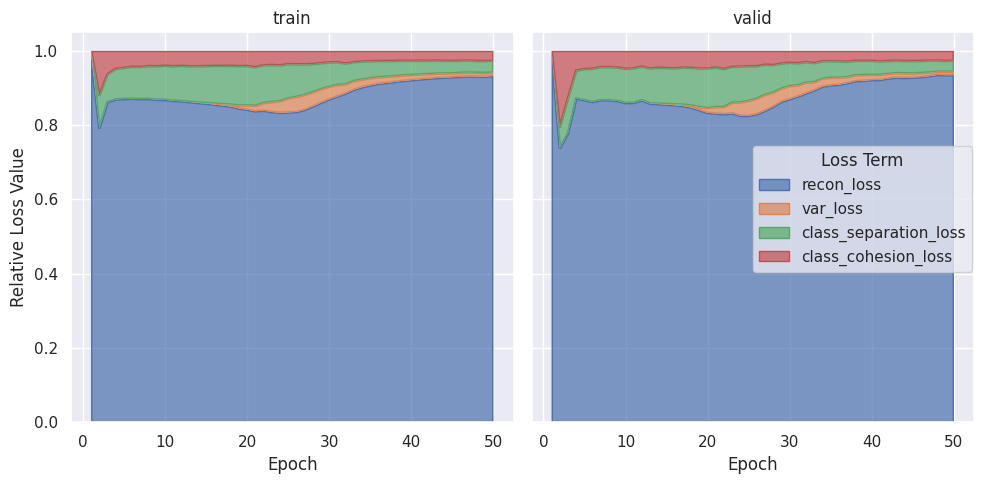

In [26]:

supervis.visualizer.show_loss(plot_type="relative")

We can visualize our standard plots with `show_result`:


Creating plots ...


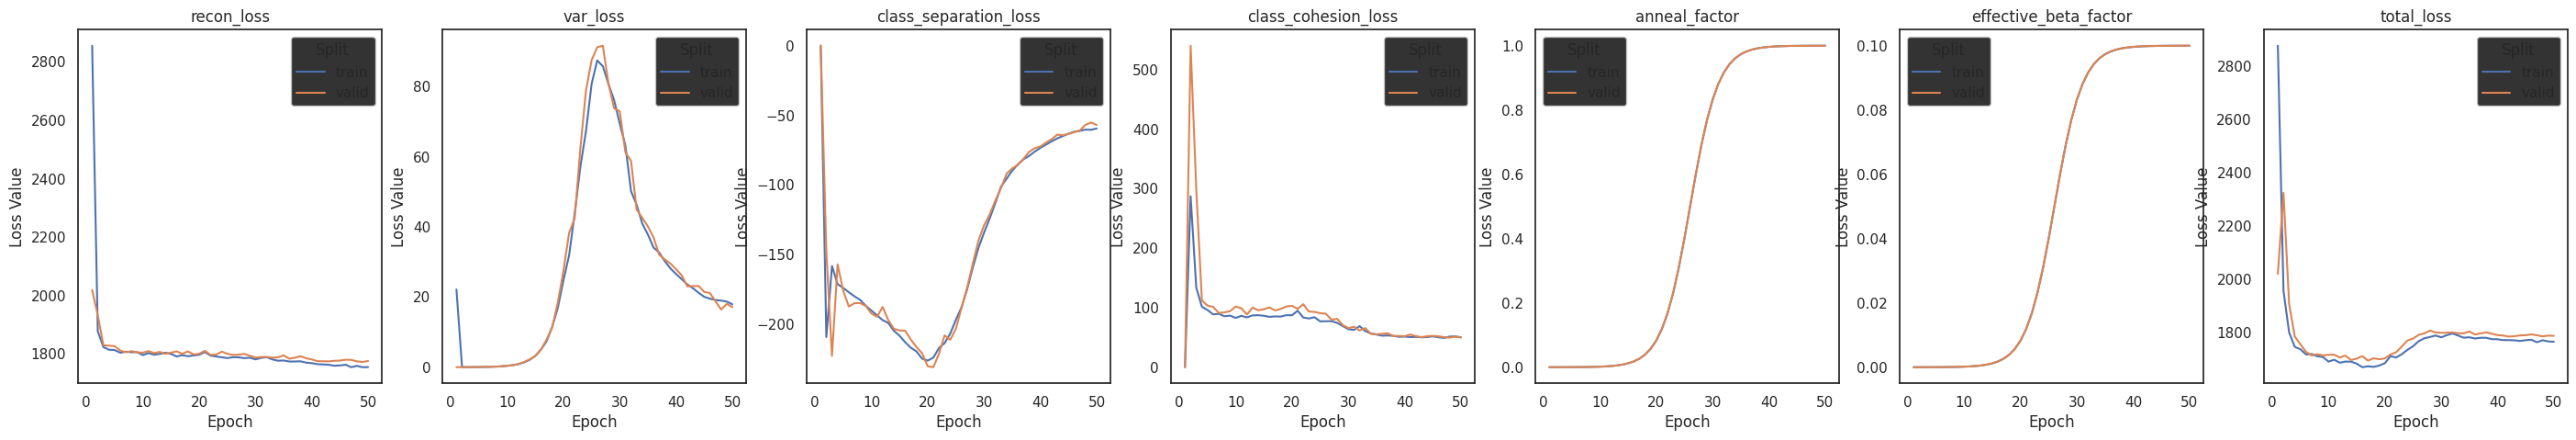

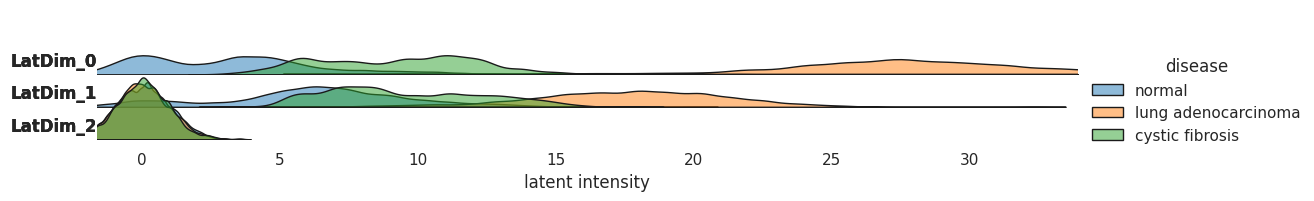

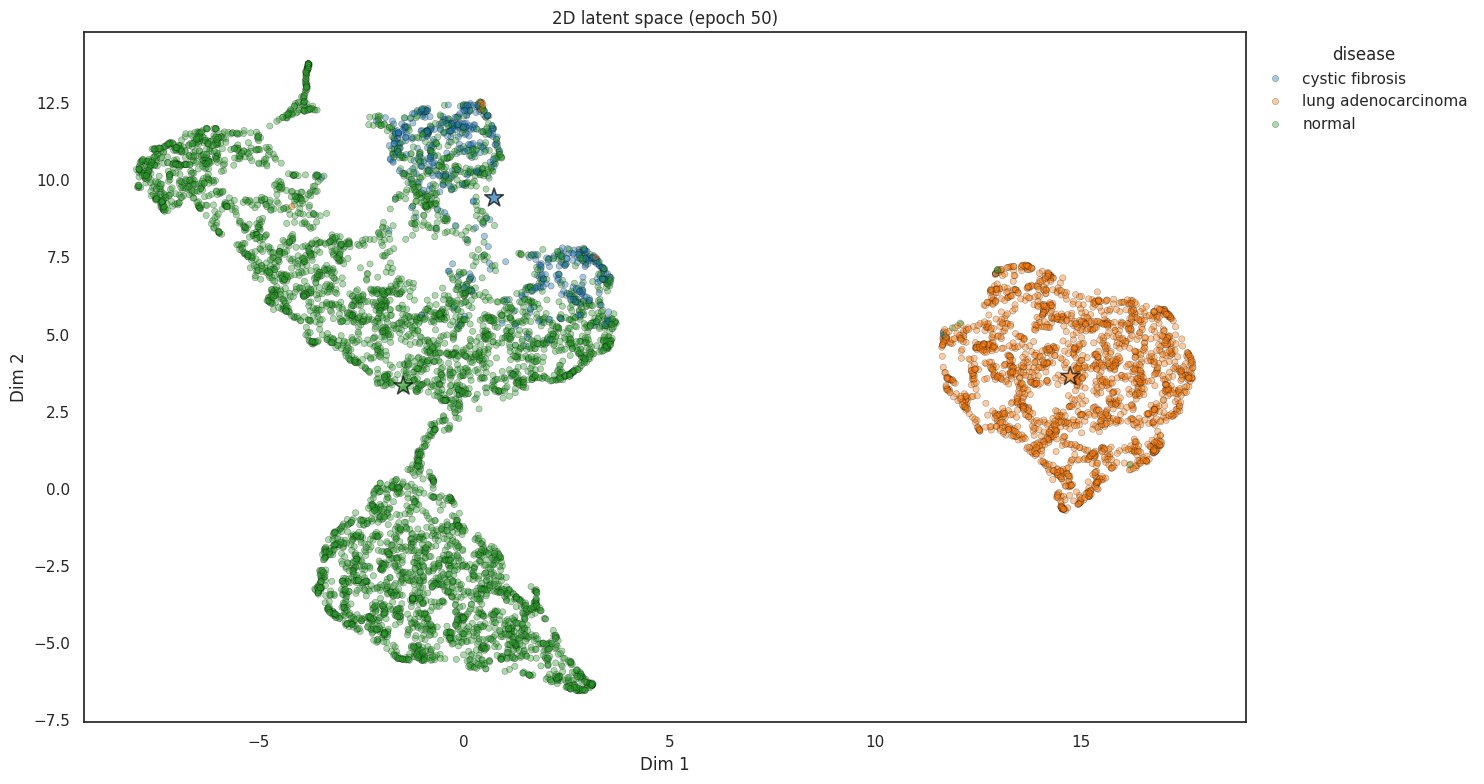

In [ ]:

supervis.show_result(params=["disease"])


### Comparing to a standard VAE run without the class-based losses

To better showcase the effect of the class-based losses, we run the plain Varix on the same data with the same set of general parameters and compare the separation classes to the Supervisix results.

In [29]:
from autoencodix.configs.varix_config import VarixConfig

my_cfg2 = VarixConfig(
	data_case=DataCase.MULTI_SINGLE_CELL,
	loss_reduction="sum",
	k_filter=2000,
	latent_dim=3,
	scaling="STANDARD",
	epochs=50,
	learning_rate=0.01,
	batch_size = 128,
	beta = 0.1,
	use_mss = True,
	drop_p =0.1,
	global_seed=7,
	reproducible=True,
	checkpoint_interval=10,
	n_layers=1,
	annotation_columns=["cell_type", "disease"],
	data_config=DataConfig(
		data_info={"multi_sc": DataInfo(is_single_cell=True, data_type="NUMERIC")},
	),
)

varix = acx.Varix(data=sc_data, config=my_cfg2)

in handle_direct_user_data with data: <class 'autoencodix.data.datapackage.DataPackage'>


In [30]:
result2 = varix.run()

mudata: View of MuData object with n_obs × n_vars = 8000 × 8189
  var:	'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'
  1 modality
    rna:	8000 x 8189
      obs:	'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'n_genes'
      var:	'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'
Processing 1 MuData objects: ['multi_sc']
Processing train modality: multi_sc
Processing valid split

/net/ifs1/san_projekte/projekte/genstat/09_nutzer/kmueller/ScaDS/NK_Alliance/autoencodix_package_custom_vae_dev/src/autoencodix/trainers/_general_trainer.py:282: UserWarning: Gradient clipping was first applied in epoch 0. Total norm of gradients (adjusted for number of features): 35.2830 exceeded max norm of 5.
  warnings.warn(


Epoch 10 - Train Loss: 1786.1190
Sub-losses: recon_loss: 1777.8603, var_loss: 8.2587, anneal_factor: 0.0017, effective_beta_factor: 0.0002
Epoch 10 - Valid Loss: 2060.4436
Sub-losses: recon_loss: 2059.3068, var_loss: 1.1368, anneal_factor: 0.0017, effective_beta_factor: 0.0002
Epoch 20 - Train Loss: 1743.4423
Sub-losses: recon_loss: 1737.9589, var_loss: 5.4834, anneal_factor: 0.0832, effective_beta_factor: 0.0083
Epoch 20 - Valid Loss: 1812.6911
Sub-losses: recon_loss: 1807.1014, var_loss: 5.5897, anneal_factor: 0.0832, effective_beta_factor: 0.0083
Epoch 30 - Train Loss: 1752.7409
Sub-losses: recon_loss: 1739.8599, var_loss: 12.8810, anneal_factor: 0.8320, effective_beta_factor: 0.0832
Epoch 30 - Valid Loss: 1818.8963
Sub-losses: recon_loss: 1806.1059, var_loss: 12.7904, anneal_factor: 0.8320, effective_beta_factor: 0.0832
Epoch 40 - Train Loss: 1754.7488
Sub-losses: recon_loss: 1741.3869, var_loss: 13.3619, anneal_factor: 0.9963, effective_beta_factor: 0.0996
Epoch 40 - Valid Loss: 1

Creating plots ...


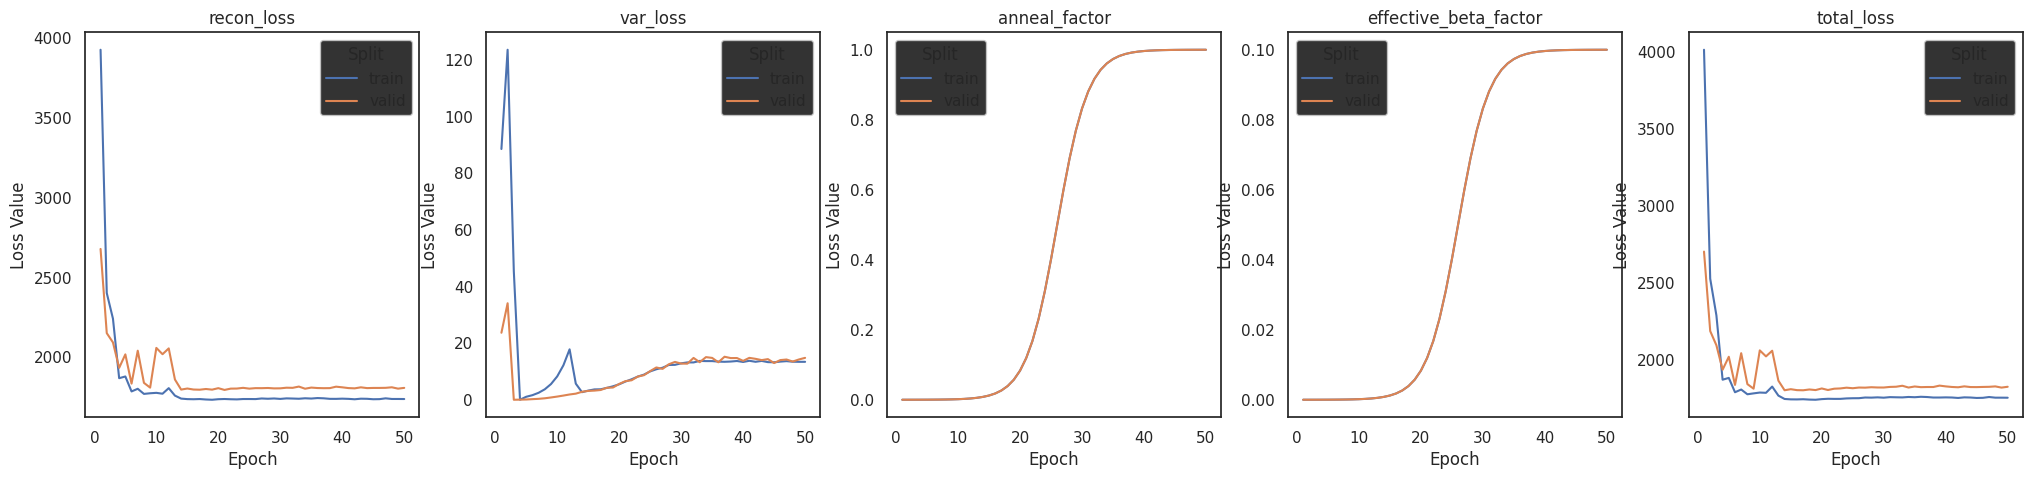

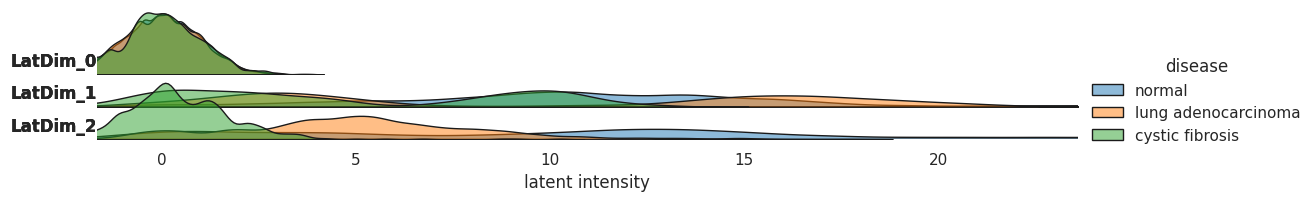

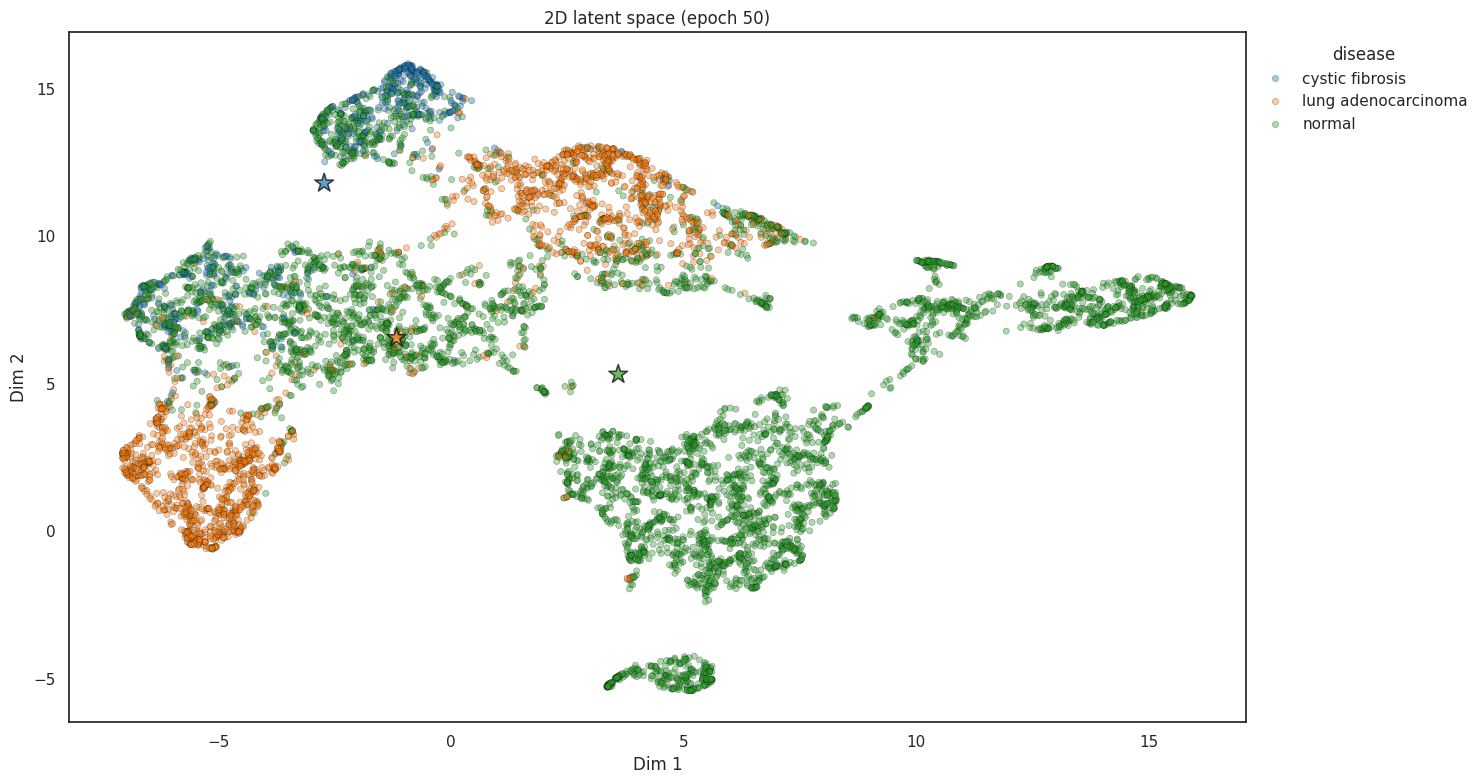

In [33]:
varix.show_result(params=["disease"])

Compare these plots to the first run's plots above: without the class-based losses the classes of the diseases in the data set appear much less cleanly separated and samples within a class are more spread out in the latents space.

#### 3.3) Save and Load Supervisix

There are no `Supervisix` specific steps here. See the `Getting Started - Vanillix` for details. Below is a basic save/load usecase:

In [34]:
import glob
import os
outpath = os.path.join("tutorial_res", "supervisix")
supervis.save(file_path=outpath, save_all=True)

folder = os.path.dirname(outpath)
pkl_files = glob.glob(os.path.join(folder, "*.pkl"))
model_files = glob.glob(os.path.join(folder, "*.pth"))

print("PKL files:", pkl_files)
print("Model files:", model_files)

# the load functionality automatically will build the pipeline object out of the three saved files
supervis_loaded = acx.Supervisix.load(outpath)

Preprocessor saved successfully.
Pipeline object saved successfully.
PKL files: ['tutorial_res/supervisix_preprocessor.pkl']
Model files: ['tutorial_res/supervisix_model.pth']
Attempting to load a pipeline from tutorial_res/supervisix...
Pipeline object loaded successfully. Actual type: Supervisix
Preprocessor loaded successfully.


In [35]:
supervis_loaded.predict(data=supervis.result.datasets)


Reproducibility settings for device auto are not implemented or necessary i.e. for cpu.


Result Object Public Attributes:
------------------------------
latentspaces: TrainingDynamics object
sample_ids: TrainingDynamics object
reconstructions: TrainingDynamics object
mus: TrainingDynamics object
sigmas: TrainingDynamics object
losses: TrainingDynamics object
sub_losses: LossRegistry(_losses={'recon_loss': TrainingDynamics(), 'var_loss': TrainingDynamics(), 'class_separation_loss': TrainingDynamics(), 'class_cohesion_loss': TrainingDynamics(), 'anneal_factor': TrainingDynamics(), 'effective_beta_factor': TrainingDynamics()})
preprocessed_data: Tensor of shape (0,)
model: VarixArchitecture
model_checkpoints: TrainingDynamics object
class_means: TrainingDynamics object
datasets: DatasetContainer(train=<autoencodix.data._numeric_dataset.NumericDataset object at 0x7f6ebebf44c0>, valid=<autoencodix.data._numeric_dataset.NumericDataset object at 0x7f6e97eb5a20>, test=<autoencodix.data._numeric_dataset.NumericDataset object at 0x7f6e9757b4c0>)
new_datasets: DatasetContainer(train=

Creating plots ...


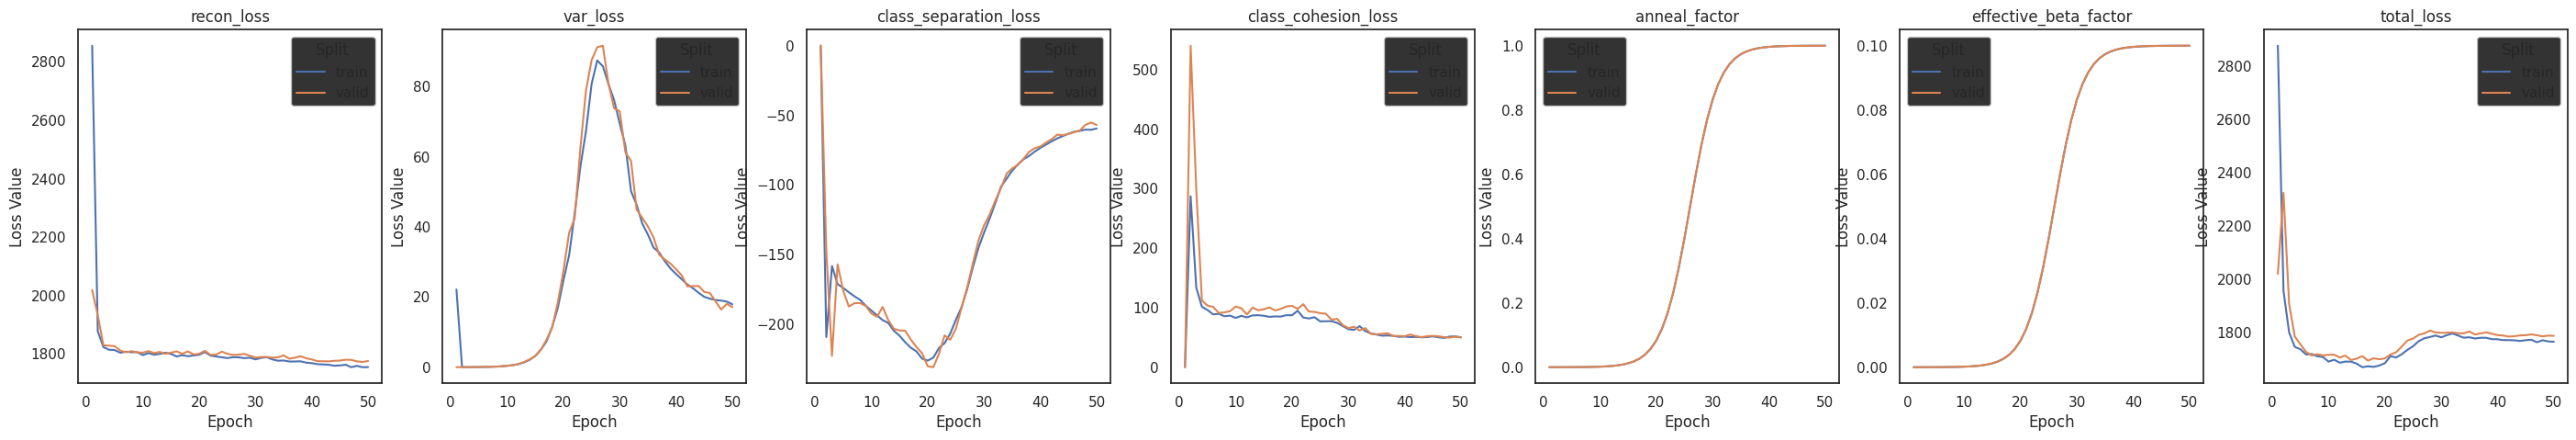

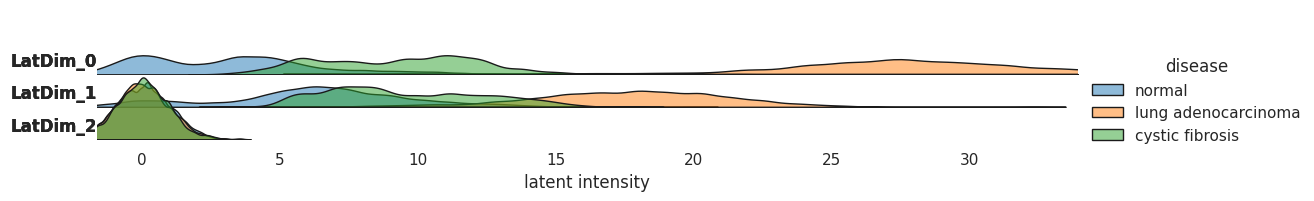

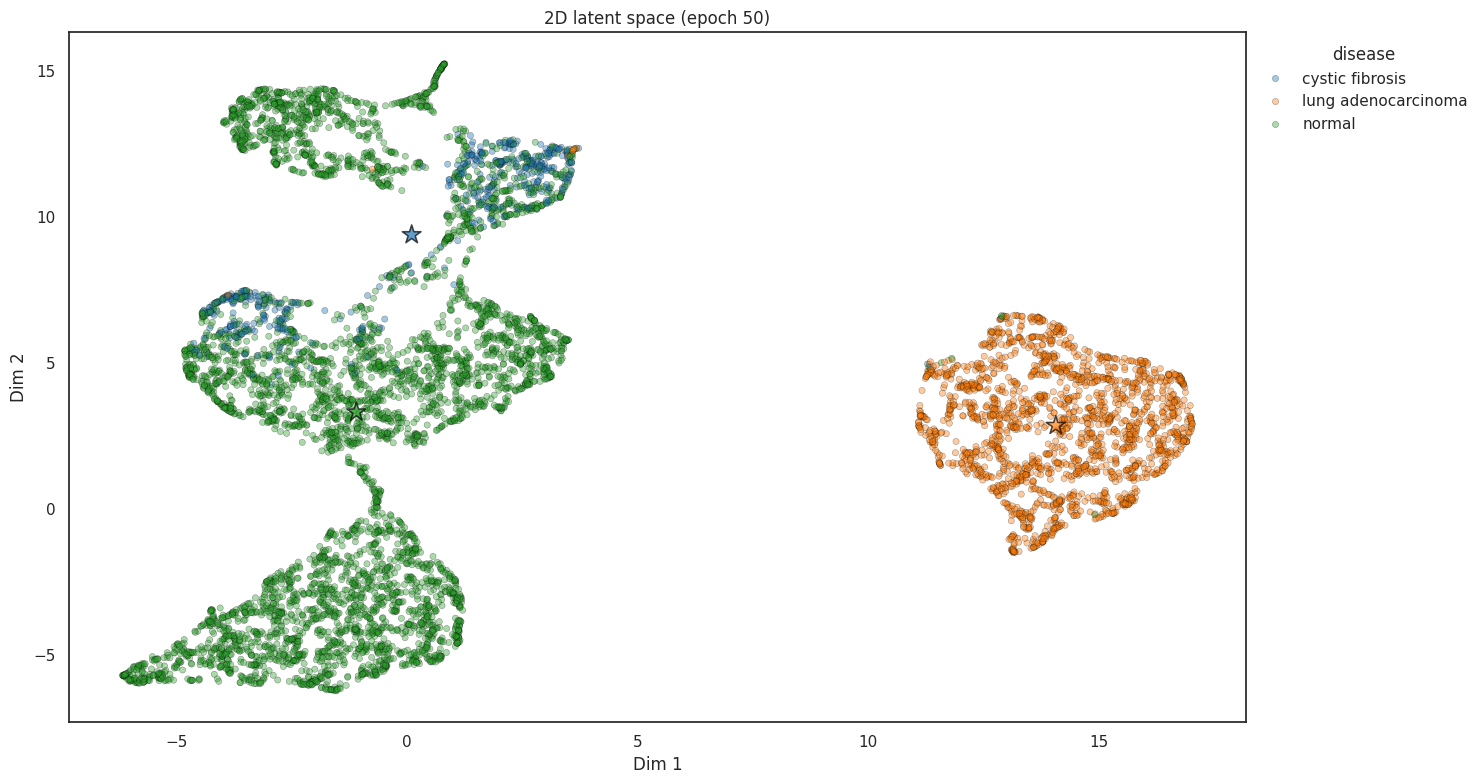

In [37]:

supervis_loaded.show_result(params=["disease"])


#### Generate New Data
For a variational autoencoder, the generate or sample_latent_space step draws new latent vectors from the model’s learned latent distribution.

**Latent Sampling:** 
The model first aggregates the posterior over all encoded latent vectors in the chosen split and epoch by computing the mean (global_mu) and log-variance (global_logvar). It then samples new latent points from a diagonal Gaussian defined by these aggregate statistics, using the reparameterization trick to inject Gaussian noise.

**Number of Samples (n_samples):** 
Users can specify how many latent points to generate. The method expands the aggregated mean and log-variance to match the requested number of samples before sampling.

**Custom Latent Prior:** 
Optionally, a custom latent_prior can be provided (a tensor or NumPy array with shape (n_samples, latent_dim)), which will be used directly instead of the aggregated posterior. This is basically the `decode` step.


In [38]:
reconstructions_generated = supervis_loaded.generate(n_samples=5)
print(reconstructions_generated.shape)

Reproducibility settings for device auto are not implemented or necessary i.e. for cpu.
torch.Size([5, 2000])
